In [1]:
import os

parent_dir = os.path.dirname(os.getcwd())
os.chdir(parent_dir)

In [2]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
from geoflow import FlowDataFrame
from geoflow import read_csv, read_file
from geoflow.array import flows_from_od

In [4]:
fdf = read_csv('./data/sz_data/sz_taxi_flow.csv', use_cols=['ox', 'oy', 'dx', 'dy'], crs='EPSG:4326')
fdf.shape, type(fdf)

((10000, 10), geoflow.flowdataframe.FlowDataFrame)

In [5]:
df = pd.read_csv('./data/sz_data/sz_taxi_flow.csv')
fdf = FlowDataFrame(df, geometry=flows_from_od(df[['ox', 'oy']], df[['dx', 'dy']]), crs='EPSG:4326')
type(fdf)

geoflow.flowdataframe.FlowDataFrame

In [6]:
fdf.to_crs(4526, inplace=True)
type(fdf)

geoflow.flowdataframe.FlowDataFrame

In [7]:
type(fdf.iloc[:100])

geoflow.flowdataframe.FlowDataFrame

In [8]:
fdf = fdf.to_crs(4526)
type(fdf)

geoflow.flowdataframe.FlowDataFrame

In [9]:
fdf.density, fdf.volume

(3.508335763442165e-06, 2850354320.18873)

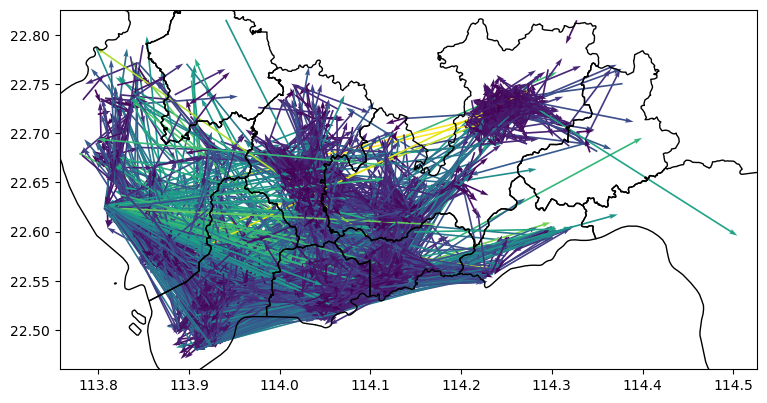

In [10]:
fdf.to_crs(4326, inplace=True)
gdf = gpd.read_file('./data/sz_data/sz_border.gpkg')
ax = fdf.plot(figsize=(9, 6), column='distance')
gdf.plot(ax=ax, facecolor="none", edgecolor="black");

In [11]:
fdf = read_file('./data/sys_flow/sys_flow_dataset2.gpkg')
fdf.head(1)

,index,ox,oy,dx,dy,angle,length,flow_type,type_num,geometry
0,0,0.933863,0.056809,0.977145,0.494712,1.4725,1.099471,scatter2,7,"MULTIPOINT (0.93386 0.056809, 0.97714 0.49471)"


In [12]:
type(fdf)

geoflow.flowdataframe.FlowDataFrame

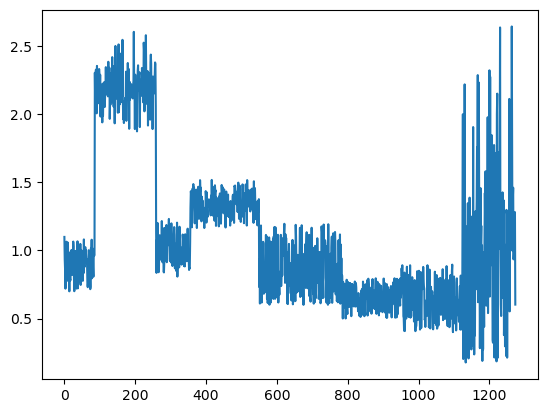

In [13]:
fdf['length'].plot(kind='line');

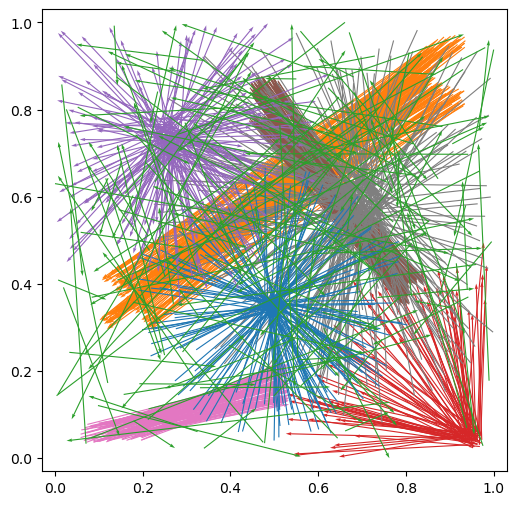

In [14]:
from matplotlib.colors import ListedColormap
labels = fdf['flow_type']
unique_labels = list(set(labels))
num_unique_labels = len(unique_labels)
cmap = ListedColormap(plt.cm.tab10.colors[:num_unique_labels]) 
label_to_color = {label: cmap(i) for i, label in enumerate(unique_labels)}
colors = [label_to_color[label] for label in labels]

fdf.plot(color=colors, figsize=(6, 6));